In [4]:
from preload import *
import statsmodels.formula.api as smf
linewidth=3
ticklabel_fontsize=25
label_fontsize=25
title_fontsize=22
title_x_postion=-.18
ylabel_y_postion=-1
labelpad=16
plt.rcParams['font.family']=['Helvetica']

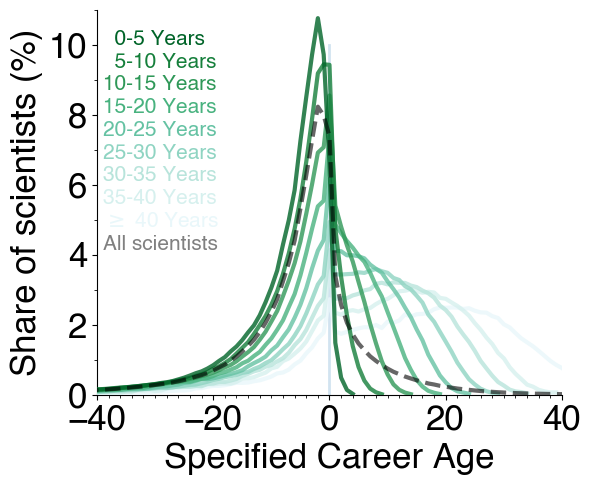

In [8]:
fig = plt.figure(figsize=(6,5),facecolor='white')
def add_space(i):
    if len(str(i))==1:
        return '  '+str(i)
    else:
        return str(i)
Y={}
with open('./FigureData/FigureData1_Dict_3_1960_rm_lateref.txt','r')as f:
    for line in f:
        tmp =line.strip().split('\t')
        a = int(tmp[0]) if tmp[0]!='all' else 'all'
        Y[a]=[np.array(json.loads(tmp[1])),np.array(json.loads(tmp[2]))]


plt.plot([0,0],[0,0.1],alpha=.2,lw=2)
legend_height=.0065
for i in [0, 5,10,15,20,25,30,35]:
    a,b= Y[i]
    b=(b[1:]+b[:-1])/2
    a=a/sum(a)
    new_lst=[[i,j] for i,j in zip(b,a) if j>0]
    a=[j for i,j in new_lst]
    b=[i for i,j in new_lst]
    plt.plot(b,a,color=plt.cm.BuGn(0.9-i/50),lw=linewidth,alpha=.8,zorder=50-i)
    plt.text(-40+1,.1-i/5*legend_height,'%s-%d Years'%(add_space(i),i+5),color=plt.cm.BuGn(0.9-i/50),fontsize=15)
i=40
a,b= Y[i]
plt.plot((b[1:]+b[:-1])/2,a/sum(a),color=plt.cm.BuGn(0.9-i/50),lw=linewidth,alpha=.8,zorder=50-i)
plt.text(-40+1,.1-i/5*legend_height,'$\geq$ %d Years'%(40),color=plt.cm.BuGn(0.9-i/50),fontsize=15)
i=45
a,b= Y['all']
plt.plot((b[1:]+b[:-1])/2,a/sum(a),'--',color='k',lw=linewidth,alpha=.6,label='All',zorder=100)
plt.text(-40+1,.1-i/5*legend_height,'All scientists',fontsize=15,color='gray')

plt.xlim(-40,40)
plt.ylim(0,0.11)
ax=plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.xaxis.set_minor_locator(plt.MultipleLocator(2))
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.01))
ax.tick_params(axis='both', which='major', labelsize=ticklabel_fontsize)
plt.ylabel('Share of scientists (%)',fontsize=label_fontsize)
plt.xlabel('Specified Career Age',fontsize=label_fontsize)
plt.yticks([0.,0.02,0.04,0.06,0.08,0.1,],['0','2','4','6','8','10'])
plt.savefig('./fig/F1.pdf',bbox_inches='tight')